# Model Definition and Evaluation
## Table of Contents
1. [Model Selection](#model-selection)
2. [Feature Engineering](#feature-engineering)
3. [Hyperparameter Tuning](#hyperparameter-tuning)
4. [Implementation](#implementation)
5. [Evaluation Metrics](#evaluation-metrics)
6. [Comparative Analysis](#comparative-analysis)


In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, mean_squared_error, classification_report

# Import models you're considering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.metrics import mean_absolute_error
from sklearn.impute import SimpleImputer

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l1_l2

import matplotlib.pyplot as plt

2026-02-15 09:26:51.013743: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-15 09:26:51.070247: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-15 09:26:53.033191: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-15 09:26:55.937364: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

## Model Selection

We initially experimented with a neural network model similar to the example provided in Week 8. However, this reference model did not distinguish between different product groups and therefore did not learn group-specific patterns. To address this, we attempted to improve performance by applying feature-level adjustments for product groups 4 and 6 prior to training, which led to only marginal improvements.

Subsequently, we implemented a feedforward neural network that does not rely on recurrent connections and is therefore computationally more efficient. This architecture allowed us to train separate models for each product group, enabling the network to better capture group-specific characteristics. In particular, the performance for product group 4 improved noticeably. Given its superior results, faster training time, and improved interpretability, we selected the feedforward neural network as our final model.


## Feature Engineering

Additional feature engineering was conducted to enhance the model's ability to capture temporal patterns and seasonality in sales data. Calendar-related features such as month, day of year, weekend indicators, and public and school holidays were added. Seasonal effects were encoded using sine and cosine transformations of the day of year. Furthermore, lagged sales features (1, 2, 7, and 14 days) and rolling statistics (mean and standard deviation over 7, 14, and 30 days) were computed per product group, with a one-day shift applied to avoid information leakage. Weekdays were also one-hot encoded to model systematic intra-week effects.


In [4]:
#Load the dataset and split it
train = pd.read_csv("train_split_merged_expanded_data.csv", parse_dates=["date"])
val   = pd.read_csv("val_split_merged_expanded_data.csv", parse_dates=["date"])
test  = pd.read_csv("test_split_merged_expanded_data_filtered.csv", parse_dates=["date"])

print("Train:", train.shape, "Val:", val.shape, "Test:", test.shape)
print("Train dates:", train["date"].min(), "→", train["date"].max())
print("Val dates:", val["date"].min(), "→", val["date"].max())
print("Test dates:", test["date"].min(), "→", test["date"].max())


#Perform the above described feature engineering steps
def add_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["date"] = pd.to_datetime(df["date"])
    
    #Calendar features
    df["Wochentag"] = df["date"].dt.day_name()
    df["Month"]     = df["date"].dt.month
    df["dayofyear"] = df["date"].dt.dayofyear

    #Seasonality encoding (cyclical)
    df["sin_season"] = np.sin(2 * np.pi * df["dayofyear"] / 365)
    df["cos_season"] = np.cos(2 * np.pi * df["dayofyear"] / 365)

    df["is_weekend"] = df["Wochentag"].isin(["Saturday", "Sunday"]).astype(int)

    #Integer/calendar flags (force 0/1 and no NaNs)
    for col in ["KielerWoche", "school_holiday", "public_holiday"]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

    return df

train_fe = add_features(train)
val_fe   = add_features(val)
test_fe  = add_features(test)

print("Feature engineering done.")

#additional
train_fe["dataset"] = "train"
val_fe["dataset"]   = "val"
test_fe["dataset"]  = "test"

df_all = pd.concat([train_fe, val_fe, test_fe], ignore_index=True)
df_all = df_all.sort_values(["warengruppe", "date"])

#Lags of target (umsatz) capture short-term and weekly memory
for lag in [1, 2, 7, 14]:
    df_all[f"lag_{lag}"] = df_all.groupby("warengruppe")["umsatz"].shift(lag)

#Rolling mean & std
for window in [7, 14, 30]:
    df_all[f"roll{window}_mean"] = (
        df_all.groupby("warengruppe")["umsatz"].shift(1).rolling(window).mean()
    )
    df_all[f"roll{window}_std"] = (
        df_all.groupby("warengruppe")["umsatz"].shift(1).rolling(window).std()
    )

#One-hot weekday (done on ALL so columns match across splits)
df_all = pd.get_dummies(df_all, columns=["Wochentag"], drop_first=True)

train_fe = df_all[df_all["dataset"] == "train"].copy()
val_fe   = df_all[df_all["dataset"] == "val"].copy()
test_fe  = df_all[df_all["dataset"] == "test"].copy()

print("Lag + rolling + one-hot done.")

#Feature and target variable selection
weekday_cols = [c for c in train_fe.columns if c.startswith("Wochentag_")]

feature_cols = [
    "Temperatur",
    "KielerWoche",
    "school_holiday",
    "public_holiday",
    "Month",
    "sin_season",
    "cos_season",
    "is_weekend",
    "lag_1",
    "lag_2",
    "lag_7",
    "lag_14",
    "roll7_mean",
    "roll7_std",
    "roll14_mean",
    "roll14_std",
    "roll30_mean",
    "roll30_std",
] + weekday_cols

target_col = "umsatz"

print("Number of features:", len(feature_cols))


Train: (7475, 11) Val: (1840, 11) Test: (1830, 11)
Train dates: 2013-07-01 00:00:00 → 2017-07-31 00:00:00
Val dates: 2017-08-01 00:00:00 → 2018-07-31 00:00:00
Test dates: 2018-08-01 00:00:00 → 2019-07-30 00:00:00
Feature engineering done.
Lag + rolling + one-hot done.
Number of features: 24


## Hyperparameter Tuning

No explicit hyperparameter tuning (e.g. grid search or random search) was performed. Model parameters and feature configurations were selected manually based on prior knowledge and empirical testing.


In [5]:
# Implement hyperparameter tuning
# Example using GridSearchCV with a DecisionTreeClassifier
# param_grid = {'max_depth': [2, 4, 6, 8]}
# grid_search = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5)
# grid_search.fit(X_train, y_train)


## Implementation

While adapting our neural network code to the required notebook structure, we encountered the issue that our original implementation and evaluation were combined within a single loop and therefore located in one cell. However, in Python, control structures such as loops and conditional blocks cannot be split across multiple notebook cells without causing syntax errors.

To comply with the required structure (separate "Implementation" and "Evaluation" cells) while keeping the training and evaluation logic intact, we encapsulated the complete training loop inside a function in the Implementation cell and execute this function in the Evaluation cell.


In [6]:
# Implement the final model(s)
#the base Neural Net
def build_model(input_dim: int) -> tf.keras.Model:
    model = Sequential([
        Dense(64, activation="relu", input_shape=(input_dim,)),
        Dropout(0.1),
        Dense(32, activation="relu"),
        Dense(1)
    ])

    model.compile(
        optimizer="adam",
        loss="mse"
    )
    return model

def train_and_collect_results():
    """
    Train neural network models for each product group and collect results.
    Returns results DataFrame, predictions list, and trained models dictionary.
    """
    results = []
    pred_list = []
    models_by_wg = {}
    
    product_groups = sorted(train_fe["warengruppe"].dropna().unique())
    
    for wg in product_groups:
        print("\n==============================")
        print(f" Warengruppe {wg}")
        print("==============================")

        train_wg = train_fe[train_fe["warengruppe"] == wg].copy()
        val_wg   = val_fe[val_fe["warengruppe"] == wg].copy()
        test_wg  = test_fe[test_fe["warengruppe"] == wg].copy()

        #Drop rows without target in train/val
        train_wg = train_wg.dropna(subset=[target_col])
        val_wg   = val_wg.dropna(subset=[target_col])

        #Drop rows with missing FEATURES in train/val only
        train_wg = train_wg.dropna(subset=feature_cols)
        val_wg   = val_wg.dropna(subset=feature_cols)

        #DO NOT drop test rows
        print(f"Rows: train={len(train_wg)}, val={len(val_wg)}, test={len(test_wg)}")

        if len(train_wg) < 50 or len(val_wg) < 20:
            print("Too few rows for stable NN training → skipping this WG.")
            continue

        if len(test_wg) == 0:
            print("No test rows for this WG → skipping prediction.")
            continue

        #Build X/y AFTER filtering
        X_train = train_wg[feature_cols].to_numpy()
        y_train = train_wg[target_col].to_numpy()

        X_val   = val_wg[feature_cols].to_numpy()
        y_val   = val_wg[target_col].to_numpy()

        X_test  = test_wg[feature_cols].to_numpy()

        #special for WG 4: log transform targets
        if wg in [4]:
            y_train_log = np.log1p(y_train)
            y_val_log = np.log1p(y_val)

        #Impute
        imputer = SimpleImputer(strategy="mean")
        X_train = imputer.fit_transform(X_train)
        X_val   = imputer.transform(X_val)
        X_test  = imputer.transform(X_test)

        #Scale
        scaler = StandardScaler()
        X_train = scaler.fit_transform(X_train)
        X_val   = scaler.transform(X_val)
        X_test  = scaler.transform(X_test)

        #Train
        if wg in [4]:
            model = Sequential([
                Dense(128, activation="relu", input_shape=(X_train.shape[1],), kernel_regularizer=l1_l2(l1=0.001, l2=0.002)),
                Dropout(0.25),
                Dense(64, activation="relu", kernel_regularizer=l1_l2(l1=0.0005, l2=0.001)),
                Dense(1)
            ])
            model.compile(optimizer="adam", loss="mse")
        else:
            model = build_model(input_dim=X_train.shape[1])
        
        es = EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)

        if wg in [4]:
            model.fit(
                X_train, y_train_log,
                validation_data=(X_val, y_val_log),
                epochs=200,
                batch_size=32,
                callbacks=[es],
                verbose=0
            )
        else:
            model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=200,
                batch_size=32,
                callbacks=[es],
                verbose=0
            )

        #Evaluate
        if wg in [4]:
            y_train_pred = np.expm1(model.predict(X_train, verbose=0).ravel())
            y_val_pred   = np.expm1(model.predict(X_val, verbose=0).ravel())
        else:
            y_train_pred = model.predict(X_train, verbose=0).ravel()
            y_val_pred   = model.predict(X_val, verbose=0).ravel()

        r2_train = r2_score(y_train, y_train_pred)
        r2_val   = r2_score(y_val, y_val_pred)

        mse_train = mean_squared_error(y_train, y_train_pred)
        mae_train = mean_absolute_error(y_train, y_train_pred)
        mape_train = mape(y_train, y_train_pred)

        mse_val = mean_squared_error(y_val, y_val_pred)
        mae_val = mean_absolute_error(y_val, y_val_pred)
        mape_val = mape(y_val, y_val_pred)

        print(f"NN R² (train): {r2_train:.3f} | MSE: {mse_train:.2f} | MAE: {mae_train:.2f} | MAPE: {mape_train:.2f}%")
        print(f"NN R² (val):   {r2_val:.3f} | MSE: {mse_val:.2f} | MAE: {mae_val:.2f} | MAPE: {mape_val:.2f}%")

        #Visualize
        import matplotlib.pyplot as plt
        plt.figure(figsize=(10, 6))
        plt.plot(y_val, label="True Umsatz", alpha=0.7)
        plt.plot(y_val_pred, label="Predicted Umsatz", alpha=0.7)
        plt.title(f"Warengruppe {wg} - True vs Predicted Umsatz (Validation Set)")
        plt.xlabel("Samples")
        plt.ylabel("Umsatz")
        plt.legend()
        plt.show()

        results.append({
            "warengruppe": wg,
            "n_val": len(val_wg),
            "r2_train": r2_train,
            "r2_val": r2_val,
            "mse_train": mse_train,
            "mae_train": mae_train,
            "mape_train": mape_train,
            "mse_val": mse_val,
            "mae_val": mae_val,
            "mape_val": mape_val
        })

        #Predict test
        if wg in [4]:
            y_test_pred = np.expm1(model.predict(X_test, verbose=0).ravel())
        else:
            y_test_pred = model.predict(X_test, verbose=0).ravel()

        pred_list.append(pd.DataFrame({
            "id": test_wg["id"].values,
            "umsatz_Prediction": y_test_pred
        }))

        models_by_wg[wg] = (model, scaler, imputer)
    
    return results, pred_list, models_by_wg

## Evaluation Metrics

Model performance is evaluated on both the training and validation sets using R², MSE, MAE, and MAPE. The coefficient of determination (R²) is used to assess how well the model explains the variance in sales, providing an overall measure of goodness of fit. The Mean Squared Error (MSE) serves as the main optimization and evaluation metric, as it penalizes larger prediction errors more strongly. The Mean Absolute Error (MAE) complements MSE by reporting the average absolute deviation between predicted and observed values in the original sales units, making it easier to interpret.

In addition, the Mean Absolute Percentage Error (MAPE) is computed to evaluate relative prediction accuracy across product groups with differing sales magnitudes. To avoid division by zero, observations with zero sales are excluded from the MAPE calculation. For product group 4, where the target variable is log-transformed during training, predictions are back-transformed prior to evaluation to ensure all metrics are reported on the original sales scale.

While R², MSE, MAE, and MAPE are reported for both the training and validation sets, validation metrics are emphasized, as they provide a more reliable estimate of the model's generalization performance on unseen data and help identify potential overfitting.

Among the metrics, particular attention was given to MAPE because it expresses errors in relative percentage terms, making it more interpretable and comparable across product groups with widely varying sales volumes, whereas R² can be less informative when target magnitudes differ significantly.

In addition, weighted summary metrics across product groups (weighted by the number of validation samples) were calculated, including R² and MAPE, to provide a single overview of model performance while accounting for differing group sizes.

To illustrate model performance, the model's predictions were visualized for each product group by plotting predicted versus true sales (Umsatz) on the validation set. This allows inspection of systematic biases, deviations, and whether the model tracks peaks and troughs in sales. For example, for product group 4, the log-transformed target was back-transformed prior to plotting to show predictions on the original scale.



 Warengruppe 1
Rows: train=1432, val=357, test=355


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-15 09:26:58.568470: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


NN R² (train): 0.625 | MSE: 596.39 | MAE: 18.40 | MAPE: 16.89%
NN R² (val):   0.532 | MSE: 840.35 | MAE: 21.67 | MAPE: 18.60%


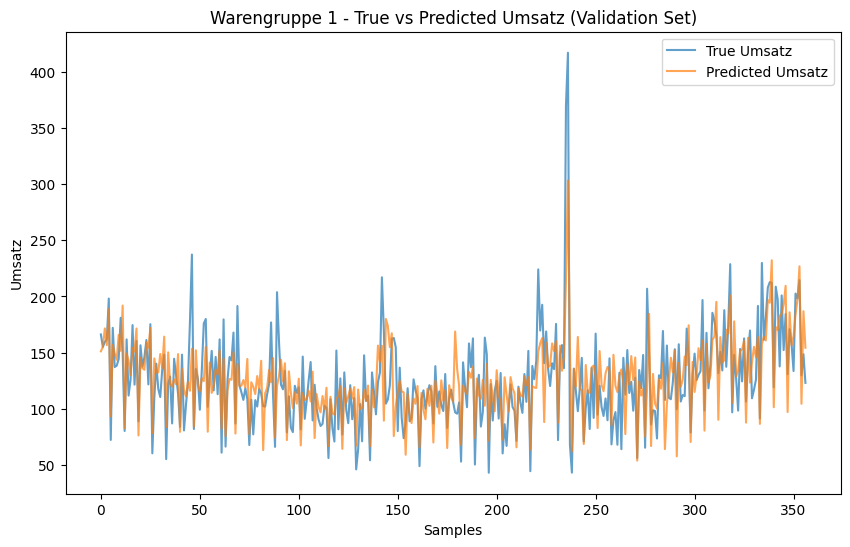


 Warengruppe 2
Rows: train=1432, val=357, test=355


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NN R² (train): 0.884 | MSE: 2201.07 | MAE: 32.01 | MAPE: 7.87%
NN R² (val):   0.894 | MSE: 1710.33 | MAE: 31.36 | MAPE: 9.08%


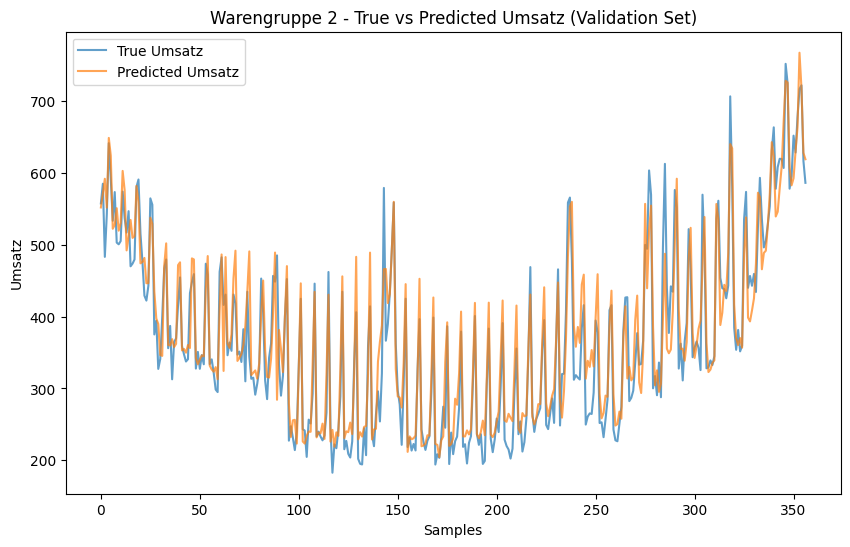


 Warengruppe 3
Rows: train=1432, val=357, test=355


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NN R² (train): 0.864 | MSE: 737.18 | MAE: 18.83 | MAPE: 12.79%
NN R² (val):   0.869 | MSE: 753.82 | MAE: 20.46 | MAPE: 14.11%


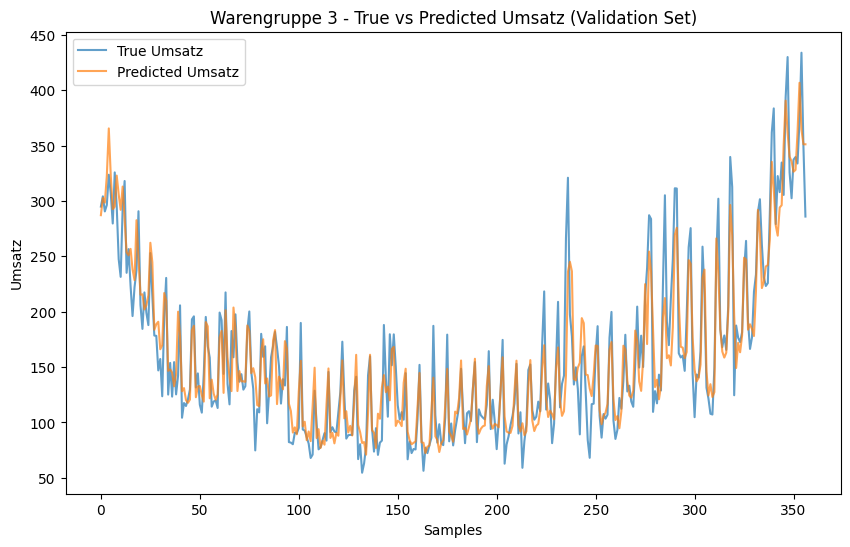


 Warengruppe 4
Rows: train=1379, val=357, test=354


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NN R² (train): 0.499 | MSE: 705.01 | MAE: 17.73 | MAPE: 19.79%
NN R² (val):   0.265 | MSE: 514.63 | MAE: 17.50 | MAPE: 21.17%


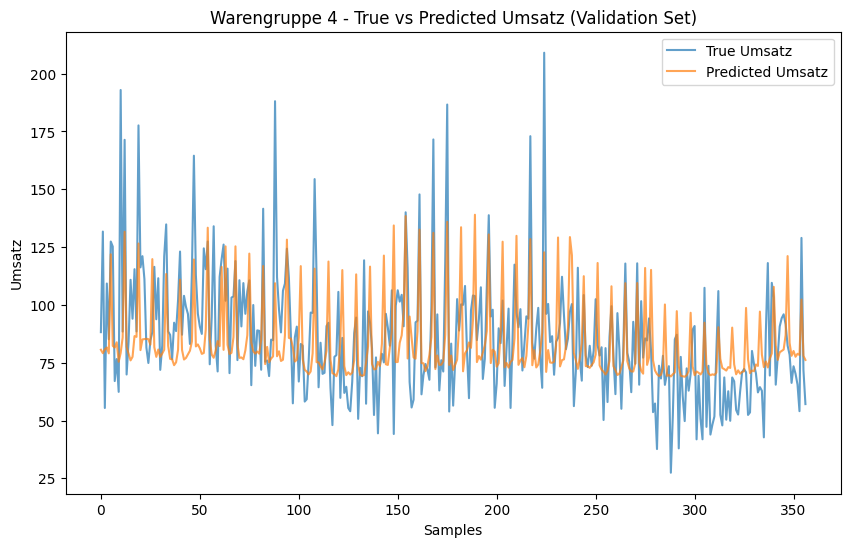


 Warengruppe 5
Rows: train=1432, val=357, test=355


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NN R² (train): 0.340 | MSE: 6867.16 | MAE: 37.12 | MAPE: 12.79%
NN R² (val):   0.211 | MSE: 6123.92 | MAE: 44.26 | MAPE: 16.82%


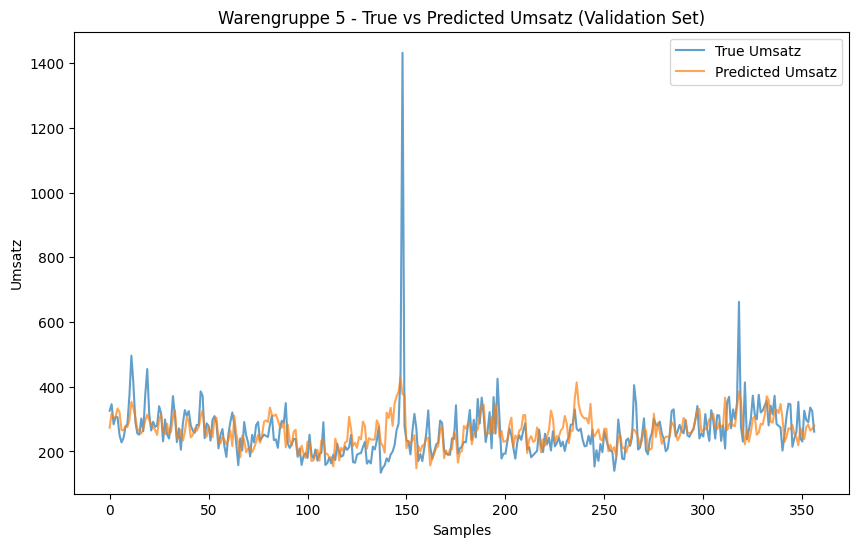


 Warengruppe 6
Rows: train=188, val=55, test=56


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


NN R² (train): 0.498 | MSE: 548.32 | MAE: 18.05 | MAPE: 31.87%
NN R² (val):   0.493 | MSE: 494.07 | MAE: 16.71 | MAPE: 41.88%


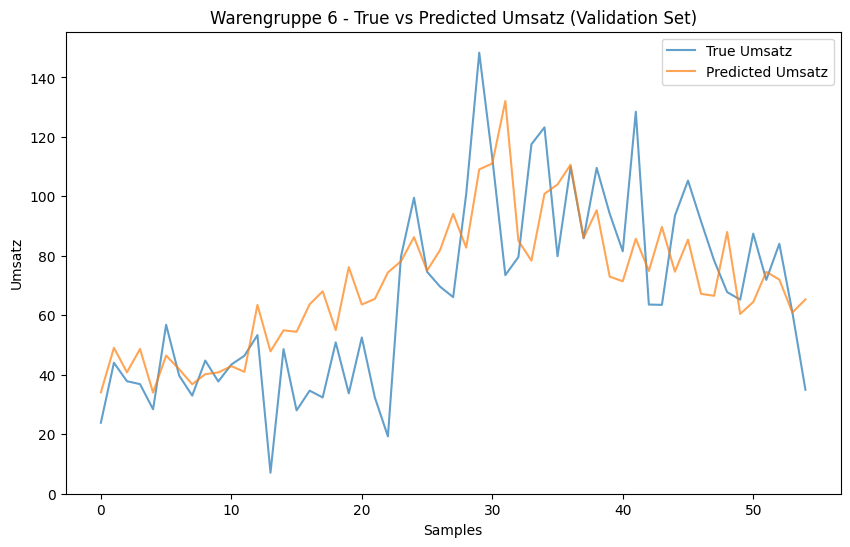

 Combined (weighted) metrics 
Weighted R² (train): 0.638
Weighted R² (val):   0.552
Weighted MAPE (val): 16.73%


,warengruppe,n_val,r2_train,r2_val,mse_train,mae_train,mape_train,mse_val,mae_val,mape_val
0,1,357,0.624827,0.531718,596.390032,18.399515,16.886491,840.346024,21.668029,18.600258
1,2,357,0.883841,0.893582,2201.066557,32.011851,7.865861,1710.331458,31.355526,9.078076
2,3,357,0.863862,0.868688,737.181306,18.832252,12.788882,753.824211,20.461139,14.114387
3,4,357,0.498572,0.264611,705.011349,17.733693,19.793315,514.631152,17.499420,21.170012
4,5,357,0.339735,0.211032,6867.156060,37.124956,12.790893,6123.923513,44.258520,16.820213
5,6,55,0.497886,0.493104,548.320255,18.050753,31.869624,494.072878,16.713796,41.884947


In [7]:
#Prepare evaluation metric
def mape(y_true, y_pred):
    """
    Mean Absolute Percentage Error (MAPE)
    Ignores zero targets to avoid division by zero.
    Returns percentage.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    non_zero_mask = y_true != 0
    if non_zero_mask.sum() == 0:
        return np.nan

    return np.mean(
        np.abs((y_true[non_zero_mask] - y_pred[non_zero_mask]) / y_true[non_zero_mask])
    ) * 100

#Execute encapsulation
results, pred_list, models_by_wg = train_and_collect_results()
results_df = pd.DataFrame(results).sort_values("warengruppe")

#Combined (weighted) evaluation
weighted_r2_train = (results_df["r2_train"] * results_df["n_val"]).sum() / results_df["n_val"].sum()
weighted_r2_val   = (results_df["r2_val"]   * results_df["n_val"]).sum() / results_df["n_val"].sum()
weighted_mape_val = (results_df["mape_val"] * results_df["n_val"]).sum() / results_df["n_val"].sum()

print(" Combined (weighted) metrics ")
print(f"Weighted R² (train): {weighted_r2_train:.3f}")
print(f"Weighted R² (val):   {weighted_r2_val:.3f}")
print(f"Weighted MAPE (val): {weighted_mape_val:.2f}%")
display(results_df)


## Comparative Analysis

[Compare the performance of your model(s) against the baseline model. Discuss any improvements or setbacks and the reasons behind them.]


In [8]:
# Comparative Analysis code (if applicable)
# Example: comparing accuracy of the baseline model and the new model
# print(f"Baseline Model Accuracy: {baseline_accuracy}, New Model Accuracy: {new_model_accuracy}")
